# Chapitre 4 — Nettoyage des données

**Cours : Analyse et traitement des données** · Auteur : *Issa Gueye*

## Objectifs

- Corriger les **types** (nombres stockés en texte, dates hétérogènes).
- **Normaliser** les chaînes de caractères (casse, espaces, accents, synonymes).
- Traiter les **doublons** et les **valeurs invalides**.
- Comprendre les **mécanismes de données manquantes** (MCAR, MAR, MNAR) et choisir une stratégie d'**imputation**.
- Détecter et traiter les **valeurs aberrantes**.
- Assembler le tout dans une **fonction de nettoyage reproductible**.

In [1]:
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = next(p for p in [Path("data/brutes"), Path("../data/brutes"), Path("../../data/brutes")] if p.exists())
ventes = pd.read_csv(DATA / "ventes_boutiques.csv")
print(ventes.shape)

(5120, 9)


## 0. La démarche

1. **Copier** — ne jamais modifier les données brutes.
2. **Diagnostiquer** chaque problème (chapitre 3).
3. **Corriger** problème par problème, en **comptant** ce que chaque étape change.
4. **Documenter** chaque décision (journal de nettoyage).
5. **Valider** à nouveau les règles.
6. **Encapsuler** dans une fonction / un script ré-exécutable.

## 1. Doublons

In [2]:
df = ventes.copy()
n0 = len(df)
df = df.drop_duplicates()
print(f"Doublons exacts supprimés : {n0 - len(df)}")
print("Identifiants encore dupliqués :", df["id_transaction"].duplicated().sum())

Doublons exacts supprimés : 120
Identifiants encore dupliqués : 0


> 💡 Distinguer les doublons **exacts** (même ligne) des doublons **sur la clé**
> (même identifiant, contenus différents) : ces derniers demandent une règle métier
> (garder la plus récente ? la plus complète ?) — `drop_duplicates(subset=[...], keep="last")`.

## 2. Convertir les types

### 2.1 Nombres stockés en texte : « 6 500 FCFA »

In [3]:
print(df["prix_unitaire"].sample(6, random_state=1).tolist())

['5320.0', '1580.0', '1150.0', '4700.0', '140.0', '160.0']


In [4]:
def vers_nombre(s: pd.Series) -> pd.Series:
    """Extrait un nombre d'une chaîne du type '6 500 FCFA' ou '6500.0'."""
    nettoye = (
        s.astype("str")
         .str.replace(r"[^\d,.\-]", "", regex=True)   # garde chiffres, séparateurs et signe
         .str.replace(",", ".", regex=False)          # virgule décimale -> point
    )
    return pd.to_numeric(nettoye, errors="coerce")    # ce qui reste non convertible -> NaN

df["prix_unitaire"] = vers_nombre(df["prix_unitaire"])
print(df["prix_unitaire"].dtype, "| non convertis :", df["prix_unitaire"].isna().sum())
df["prix_unitaire"].describe()

float64 | non convertis : 0


count     5000.000000
mean      2718.450000
std       3438.018553
min        130.000000
25%        630.000000
50%       1080.000000
75%       4570.000000
max      14040.000000
Name: prix_unitaire, dtype: float64

> `errors="coerce"` transforme les valeurs impossibles en `NaN` **au lieu de planter** :
> pratique, mais **toujours compter** les NaN créés pour ne pas perdre de données en silence.

### 2.2 Dates en formats multiples

In [5]:
print(df["date"].str.replace(r"\d", "9", regex=True).value_counts())

date
9999-99-99    4300
99-99-9999     350
99/99/9999     350
Name: count, dtype: int64


In [6]:
def vers_date(s: pd.Series) -> pd.Series:
    """Essaie successivement plusieurs formats explicites (plus sûr que la détection automatique)."""
    resultat = pd.Series(pd.NaT, index=s.index, dtype="datetime64[us]")
    for fmt in ["%Y-%m-%d", "%d/%m/%Y", "%d-%m-%Y"]:
        manque = resultat.isna()
        resultat[manque] = pd.to_datetime(s[manque], format=fmt, errors="coerce")
    return resultat

df["date"] = vers_date(df["date"])
print(df["date"].dtype, "| non converties :", df["date"].isna().sum())
print(df["date"].min(), "→", df["date"].max())

datetime64[us] | non converties : 0
2025-01-01 00:00:00 → 2025-12-31 00:00:00


⚠️ **Piège des dates ambiguës** : `03/04/2025` = 3 avril (France, Sénégal) ou 4 mars (États-Unis) ?
Toujours spécifier `format=` ou `dayfirst=True`, et vérifier la plage min–max obtenue.

Une fois converties, on peut extraire des composantes :

In [7]:
df["mois"] = df["date"].dt.month
df["jour_semaine"] = df["date"].dt.day_name()
df[["date", "mois", "jour_semaine"]].head(3)

,date,mois,jour_semaine
0,2025-01-19,1,Sunday
1,2025-12-12,12,Friday
2,2025-04-02,4,Wednesday


## 3. Normaliser le texte

In [8]:
def normaliser_texte(s: pd.Series) -> pd.Series:
    return (
        s.str.strip()                                   # espaces en début/fin
         .str.replace(r"\s+", " ", regex=True)          # espaces multiples
         .str.title()                                   # casse : « Saint-Louis »
    )

df["region"] = normaliser_texte(df["region"])
print(df["region"].value_counts())

region
Dakar          1488
Thiès           679
Diourbel        660
Kaolack         491
Louga           406
Ziguinchor      405
Saint-Louis     365
Tambacounda     361
St-Louis        145
Name: count, dtype: int64


Il reste un **synonyme** (`St-Louis`). On le corrige avec un dictionnaire de correspondance,
puis on **vérifie contre le référentiel officiel** :

In [9]:
correspondances = {"St-Louis": "Saint-Louis", "St Louis": "Saint-Louis"}
df["region"] = df["region"].replace(correspondances)

referentiel = pd.read_csv(DATA / "regions_senegal.csv")
hors_ref = set(df["region"].dropna()) - set(referentiel["region"])
print("Régions hors référentiel :", hors_ref or "aucune ✅")

Régions hors référentiel : aucune ✅


### Accents et comparaison « floue »
Pour comparer des chaînes saisies librement, on retire parfois les accents
(`Thiès` ≈ `Thies`) :

In [10]:
def sans_accents(texte: str) -> str:
    return "".join(c for c in unicodedata.normalize("NFKD", texte) if not unicodedata.combining(c))

print([sans_accents(x) for x in ["Thiès", "Sédhiou", "Kédougou"]])

['Thies', 'Sedhiou', 'Kedougou']


Pour les fautes de frappe (`Ziguinchorr`), on peut utiliser une **distance d'édition**
(`difflib.get_close_matches`, ou les bibliothèques `rapidfuzz` / `thefuzz`) puis **valider manuellement**.

In [11]:
import difflib

saisies = ["Ziguinchorr", "Tambakounda", "Kaolak", "Dakar"]
for s in saisies:
    print(f"{s:<12} -> {difflib.get_close_matches(s, referentiel['region'], n=1, cutoff=0.7)}")

Ziguinchorr  -> ['Ziguinchor']
Tambakounda  -> ['Tambacounda']
Kaolak       -> ['Kaolack']
Dakar        -> ['Dakar']


## 4. Valeurs invalides (règles métier)

In [12]:
invalides = df["quantite"] <= 0
extremes = df["quantite"] > 50
print(f"Quantités ≤ 0 : {invalides.sum()} | > 50 : {extremes.sum()}")
print(df.loc[extremes, "quantite"].value_counts())

Quantités ≤ 0 : 10 | > 50 : 15
quantite
100.0    7
250.0    5
999.0    3
Name: count, dtype: int64


Décision documentée : une quantité négative ou ≥ 100 dans une boutique de quartier est une
**erreur de saisie** (pas un retour produit, pas une vente en gros) → on la remplace par `NaN`
pour pouvoir l'imputer ensuite, plutôt que de supprimer toute la ligne.

In [13]:
df.loc[invalides | extremes, "quantite"] = np.nan

## 5. Données manquantes

### 5.1 Les trois mécanismes (Rubin, 1976)

| Mécanisme | Définition | Exemple | Conséquence |
|---|---|---|---|
| **MCAR** — *Missing Completely At Random* | la probabilité d'être manquant ne dépend de rien | capteur en panne au hasard | supprimer les lignes n'introduit pas de biais (mais perd de la puissance) |
| **MAR** — *Missing At Random* | dépend de variables **observées** | les urbains diplômés déclarent moins leur revenu | biais si on supprime ; corrigeable en conditionnant sur ces variables |
| **MNAR** — *Missing Not At Random* | dépend de la **valeur manquante elle-même** | les plus riches ne déclarent pas leur revenu *parce qu'*il est élevé | biais difficile à corriger ; analyses de sensibilité |

On ne peut **jamais prouver** MCAR/MAR à partir des données seules, mais on peut **explorer**.

In [14]:
menages = pd.read_csv(DATA / "enquete_menages.csv")
menages["revenu_manquant"] = menages["revenu_mensuel_fcfa"].isna()
print(f"Taux global de non-réponse : {menages['revenu_manquant'].mean():.1%}\n")
print(menages.groupby("milieu")["revenu_manquant"].mean().map("{:.1%}".format))
print(menages.groupby("education_chef")["revenu_manquant"].mean().map("{:.1%}".format))

Taux global de non-réponse : 11.8%

milieu
Rural      4.6%
Urbain    17.3%
Name: revenu_manquant, dtype: str
education_chef
Aucun          8.5%
Coranique      9.0%
Primaire      10.6%
Secondaire    14.2%
Supérieur     23.0%
Name: revenu_manquant, dtype: str


La non-réponse est **beaucoup plus fréquente** en milieu urbain et chez les diplômés du supérieur :
ce n'est **pas MCAR**. Comme ces groupes ont des revenus plus élevés, la moyenne calculée sur les
seuls répondants **sous-estime** le revenu moyen réel.

### 5.2 Visualiser les manquants

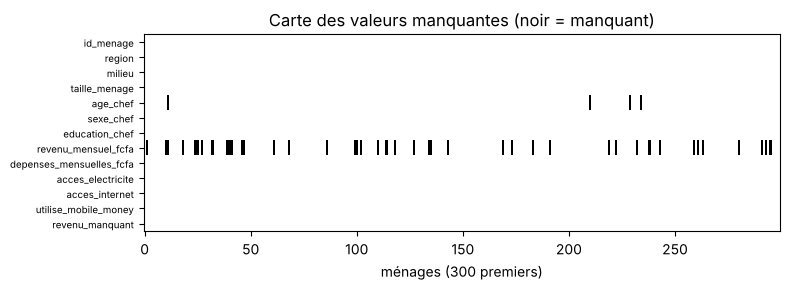

In [15]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.imshow(menages.isna().T.values[:, :300], aspect="auto", cmap="gray_r", interpolation="none")
ax.set_yticks(range(menages.shape[1]), menages.columns, fontsize=7)
ax.set_xlabel("ménages (300 premiers)")
ax.set_title("Carte des valeurs manquantes (noir = manquant)")
plt.tight_layout(); plt.show()

(La bibliothèque `missingno` produit ce type de graphique en une ligne.)

### 5.3 Stratégies

| Stratégie | Quand | Limites |
|---|---|---|
| Supprimer les lignes (`dropna`) | peu de manquants, MCAR | perte d'information, biais si MAR/MNAR |
| Supprimer la colonne | > 50–60 % de manquants et variable peu utile | perte de la variable |
| Imputer moyenne / médiane / mode | rapide, baseline | **écrase la variance**, ignore les relations |
| Imputer par groupe | MAR lié à un groupe connu | suppose l'homogénéité dans le groupe |
| KNN / régression / MICE | MAR, relations entre variables | plus complexe ; à faire *après* séparation train/test en modélisation |
| Ajouter un indicateur « était manquant » | le fait de manquer est informatif | une colonne de plus |

### 5.4 Démonstration : effet des méthodes d'imputation

On simule une « vérité » pour pouvoir **comparer** les méthodes (impossible sur données réelles).

In [16]:
rng = np.random.default_rng(0)
complet = menages.dropna(subset=["revenu_mensuel_fcfa"]).copy()
verite = complet["revenu_mensuel_fcfa"].copy()
# on retire 25 % des revenus selon un mécanisme MAR (plus de manquants chez les urbains)
p = np.where(complet["milieu"] == "Urbain", 0.35, 0.10)
masque = rng.random(len(complet)) < p
complet.loc[masque, "revenu_mensuel_fcfa"] = np.nan

methodes = {}
methodes["suppression"] = complet["revenu_mensuel_fcfa"].dropna()
methodes["moyenne"] = complet["revenu_mensuel_fcfa"].fillna(complet["revenu_mensuel_fcfa"].mean())
methodes["médiane"] = complet["revenu_mensuel_fcfa"].fillna(complet["revenu_mensuel_fcfa"].median())
methodes["médiane par groupe"] = complet["revenu_mensuel_fcfa"].fillna(
    complet.groupby(["milieu", "education_chef"])["revenu_mensuel_fcfa"].transform("median"))

**Imputation multivariée** avec scikit-learn : `KNNImputer` (moyenne des $k$ voisins les plus proches)
et `IterativeImputer` (approche de type **MICE** — *Multivariate Imputation by Chained Equations*,
van Buuren & Groothuis-Oudshoorn, 2011 — chaque variable est prédite à partir des autres, itérativement).

In [17]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (active l'API expérimentale)
from sklearn.impute import IterativeImputer, KNNImputer

X = pd.get_dummies(complet[["revenu_mensuel_fcfa", "depenses_mensuelles_fcfa", "taille_menage",
                            "milieu", "education_chef", "acces_internet"]], drop_first=True, dtype=float)
X["revenu_mensuel_fcfa"] = np.log(X["revenu_mensuel_fcfa"])          # travailler en log : distribution plus symétrique
X["depenses_mensuelles_fcfa"] = np.log(X["depenses_mensuelles_fcfa"])
methodes["KNN (k=10)"] = pd.Series(np.exp(KNNImputer(n_neighbors=10).fit_transform(X)[:, 0]), index=X.index)
methodes["Itératif (MICE)"] = pd.Series(np.exp(IterativeImputer(random_state=0).fit_transform(X)[:, 0]), index=X.index)

In [18]:
lignes = []
for nom, s in methodes.items():
    erreur = (np.abs(s[masque] - verite[masque]).mean() if nom != "suppression" else np.nan)
    lignes.append({"méthode": nom, "moyenne": s.mean(), "écart-type": s.std(),
                   "erreur abs. moy. sur imputés": erreur})
comparaison = pd.DataFrame(lignes).set_index("méthode")
comparaison.loc["VÉRITÉ"] = [verite.mean(), verite.std(), 0]
comparaison.round(0)

,moyenne,écart-type,erreur abs. moy. sur imputés
méthode,,,
suppression,264575.0,210717.0,NaN
moyenne,264575.0,182635.0,168940.0
médiane,249511.0,184503.0,173383.0
médiane par groupe,267985.0,192261.0,143087.0
KNN (k=10),271618.0,198619.0,81390.0
Itératif (MICE),279944.0,221229.0,37460.0
VÉRITÉ,280012.0,222945.0,0.0


**Lecture** :
- la **suppression** et l'imputation par la **moyenne/médiane** globale **biaisent la moyenne** (MAR !)
  et la moyenne **réduit artificiellement l'écart-type** ;
- les méthodes qui **utilisent les autres variables** (groupe, KNN, MICE) se rapprochent de la vérité.

> 📌 En modélisation, l'imputeur doit être **ajusté sur les données d'entraînement uniquement**
> (voir chapitre 8, fuite de données). Pour l'inférence statistique rigoureuse, on utilise
> l'**imputation multiple** (plusieurs jeux imputés puis règles de Rubin).

### 5.5 Séries temporelles : interpolation

Jours manquants après réindexation : 58


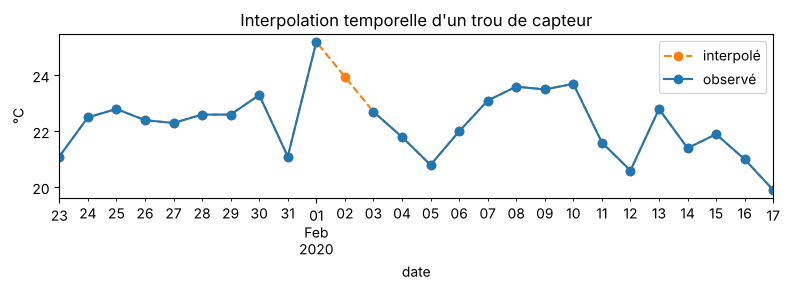

In [19]:
meteo = pd.read_csv(DATA / "meteo_dakar.csv", parse_dates=["date"]).set_index("date")
meteo.loc[meteo["temp_moy_c"] < -50, "temp_moy_c"] = np.nan          # capteur défaillant
meteo = meteo.asfreq("D")                                           # réinsère les jours absents
print("Jours manquants après réindexation :", meteo["temp_moy_c"].isna().sum())
meteo["temp_interp"] = meteo["temp_moy_c"].interpolate(method="time", limit=7)

extrait = meteo.loc["2020-01-01":"2024-12-31"]
trou = extrait["temp_moy_c"].isna()
debut = trou[trou].index[0]
fen = meteo.loc[debut - pd.Timedelta(days=10): debut + pd.Timedelta(days=15)]
ax = fen["temp_interp"].plot(style="o--", color="tab:orange", label="interpolé", figsize=(8, 3))
fen["temp_moy_c"].plot(style="o-", ax=ax, color="tab:blue", label="observé")
ax.set_ylabel("°C"); ax.legend(); ax.set_title("Interpolation temporelle d'un trou de capteur")
plt.tight_layout(); plt.show()

`ffill` (report de la dernière valeur) convient aux niveaux qui changent par paliers (prix, stocks) ;
l'interpolation linéaire/temporelle aux grandeurs continues (température) ; on fixe une **limite**
pour ne pas inventer de longues séries.

## 6. Valeurs aberrantes (*outliers*)

Une valeur aberrante peut être une **erreur** (à corriger) ou un **fait réel rare** (à garder !).
La statistique **détecte**, le **métier décide**.

### 6.1 Règle de Tukey (IQR)
Valeur suspecte si $x < Q_1 - 1{,}5\,\text{IQR}$ ou $x > Q_3 + 1{,}5\,\text{IQR}$, avec $\text{IQR} = Q_3 - Q_1$.

### 6.2 Score z robuste (médiane / MAD)
Le score $z = (x - \bar x)/s$ est lui-même sensible aux extrêmes. On préfère
$$z^{\text{rob}}_i = \frac{x_i - \operatorname{médiane}(x)}{1{,}4826 \cdot \operatorname{MAD}}, \qquad \operatorname{MAD} = \operatorname{médiane}(|x_i - \operatorname{médiane}(x)|)$$
et on signale $|z^{\text{rob}}| > 3{,}5$ (Iglewicz & Hoaglin, 1993).

In [20]:
def outliers_iqr(s: pd.Series, k: float = 1.5) -> pd.Series:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)


def outliers_mad(s: pd.Series, seuil: float = 3.5) -> pd.Series:
    med = s.median()
    mad = (s - med).abs().median()
    return ((s - med).abs() / (1.4826 * mad)) > seuil


rev = menages["revenu_mensuel_fcfa"].dropna()
print(f"IQR   : {outliers_iqr(rev).sum()} revenus signalés")
print(f"MAD   : {outliers_mad(rev).sum()} revenus signalés")
print(f"IQR sur log(revenu) : {outliers_iqr(np.log(rev)).sum()} revenus signalés")

IQR   : 155 revenus signalés
MAD   : 138 revenus signalés
IQR sur log(revenu) : 15 revenus signalés


Le revenu suit une loi **log-normale** (asymétrique à droite) : sur l'échelle brute, beaucoup de
hauts revenus *réels* sont signalés à tort. Sur l'échelle **logarithmique**, presque rien ne ressort.
👉 **Choisir l'échelle adaptée avant de détecter.**

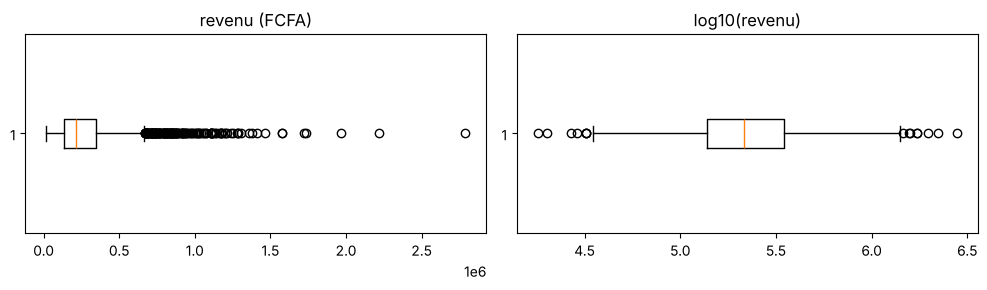

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].boxplot(rev, orientation="horizontal"); axes[0].set_title("revenu (FCFA)")
axes[1].boxplot(np.log10(rev), orientation="horizontal"); axes[1].set_title("log10(revenu)")
plt.tight_layout(); plt.show()

### 6.3 Que faire d'une valeur aberrante ?

| Diagnostic | Action |
|---|---|
| Erreur certaine (température −99 °C) | remplacer par `NaN` puis imputer |
| Erreur probable (quantité 999) | idem, et documenter |
| Valeur réelle mais extrême | garder ; utiliser des statistiques **robustes** (médiane) ou une **transformation** (log) |
| Valeur réelle qui écrase un modèle | **winsoriser** (plafonner aux percentiles 1 %–99 %) — en le signalant |

In [22]:
winsorise = rev.clip(lower=rev.quantile(0.01), upper=rev.quantile(0.99))
print(f"max brut = {rev.max():,.0f}  |  max winsorisé = {winsorise.max():,.0f}")

max brut = 2,790,000  |  max winsorisé = 1,129,050


## 7. Tout assembler : une fonction de nettoyage reproductible

On réunit les étapes dans une fonction **pure** (entrée → sortie, sans effet de bord) avec un **journal**.
C'est cette fonction (version complète dans `src/atd/nettoyage.py`) qui produit `data/propres/ventes_propres.parquet`.

In [23]:
def nettoyer_ventes(brut: pd.DataFrame, referentiel_regions: pd.Series) -> tuple[pd.DataFrame, list[str]]:
    journal = []
    df = brut.copy()

    n = len(df); df = df.drop_duplicates()
    journal.append(f"doublons exacts supprimés : {n - len(df)}")

    df["prix_unitaire"] = vers_nombre(df["prix_unitaire"])
    df["date"] = vers_date(df["date"])
    journal.append(f"dates non converties : {df['date'].isna().sum()}")

    df["region"] = normaliser_texte(df["region"]).replace({"St-Louis": "Saint-Louis"})
    inconnues = ~df["region"].isin(referentiel_regions) & df["region"].notna()
    journal.append(f"régions hors référentiel : {inconnues.sum()}")

    mauvais = (df["quantite"] <= 0) | (df["quantite"] > 50)
    df.loc[mauvais, "quantite"] = np.nan
    journal.append(f"quantités invalides -> NaN : {mauvais.sum()}")

    # imputation simple et défendable : médiane de la quantité pour le même produit
    manq = df["quantite"].isna()
    df["quantite"] = df["quantite"].fillna(df.groupby("produit")["quantite"].transform("median"))
    df["quantite_imputee"] = manq
    journal.append(f"quantités imputées (médiane par produit) : {manq.sum()}")

    df["mode_paiement"] = df["mode_paiement"].fillna("Inconnu")
    df["montant"] = df["prix_unitaire"] * df["quantite"]
    df = df.astype({"region": "category", "categorie": "category", "mode_paiement": "category",
                    "quantite": "int64"})
    return df.sort_values("date").reset_index(drop=True), journal


propres, journal = nettoyer_ventes(ventes, referentiel["region"])
print("\n".join("• " + j for j in journal))
propres.info()

• doublons exacts supprimés : 120
• dates non converties : 0
• régions hors référentiel : 0
• quantités invalides -> NaN : 25
• quantités imputées (médiane par produit) : 163
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_transaction    5000 non-null   str           
 1   date              5000 non-null   datetime64[us]
 2   region            5000 non-null   category      
 3   boutique          4937 non-null   str           
 4   produit           5000 non-null   str           
 5   categorie         5000 non-null   category      
 6   prix_unitaire     5000 non-null   float64       
 7   quantite          5000 non-null   int64         
 8   mode_paiement     5000 non-null   category      
 9   quantite_imputee  5000 non-null   bool          
 10  montant           5000 non-null   float64       
dtypes: bool(1), category(3

In [24]:
# Re-validation des règles du chapitre 3
regles = {
    "id unique": propres["id_transaction"].is_unique,
    "quantité dans [1, 50]": propres["quantite"].between(1, 50).all(),
    "région dans le référentiel": propres["region"].isin(referentiel["region"]).all(),
    "prix numérique et > 0": pd.api.types.is_numeric_dtype(propres["prix_unitaire"]) and (propres["prix_unitaire"] > 0).all(),
    "dates toutes converties": propres["date"].notna().all(),
}
pd.Series(regles, name="respectée ?")

id unique                     True
quantité dans [1, 50]         True
région dans le référentiel    True
prix numérique et > 0         True
dates toutes converties       True
Name: respectée ?, dtype: bool

In [25]:
SORTIE = DATA.parent / "propres"
SORTIE.mkdir(exist_ok=True)
propres.to_parquet(SORTIE / "ventes_propres.parquet", index=False)
print("Écrit :", SORTIE / "ventes_propres.parquet")

Écrit : ../data/propres/ventes_propres.parquet


## À retenir

- Nettoyer = suite d'étapes **diagnostiquées, comptées, documentées et reproductibles**.
- `pd.to_numeric(..., errors="coerce")`, `pd.to_datetime(..., format=...)`, méthodes `.str` : les outils de base.
- Manquants : identifier le **mécanisme** (MCAR / MAR / MNAR) avant de choisir ; la moyenne globale est rarement un bon choix.
- Aberrants : détecter avec des méthodes **robustes**, sur la **bonne échelle** ; décider avec le **métier**.

**Références** : Rubin D. B. (1976), « Inference and missing data », *Biometrika* 63(3) ;
van Buuren S. (2018), *Flexible Imputation of Missing Data*, 2ᵉ éd. (en ligne : <https://stefvanbuuren.name/fimd/>) ;
Iglewicz B. & Hoaglin D. (1993), *How to Detect and Handle Outliers*, ASQC.

➡️ **Chapitre suivant : transformer et restructurer (groupby, jointures, pivots, séries temporelles).**